---
title: "Tips"
subtitle: "DS 2023 | Communicating with Data"
type: lesson
---


## Overview

**Metadata**

- **name:** Restaurant Tips
- **description:** Tips recorded by one waiter over a few months at a single restaurant, with the bill total and attributes of each dining party.
- **provenance:** Bryant, P. G. & Smith, M. A. (1995), *Practical Data Analysis: Case Studies in Business Statistics*, Irwin/McGraw-Hill.
- **format:** long / tidy — 244 rows x 7 columns.

**Data dictionary**

- `total_bill` — *(measurement)* the bill amount in US dollars.
- `tip` — *(measurement)* the tip amount in US dollars.
- `sex` — *(identifier)* sex of the bill payer (`Male`, `Female`).
- `smoker` — *(identifier)* whether the party was in the smoking section (`Yes`, `No`).
- `day` — *(identifier)* day of the week (`Thur`–`Sun`).
- `time` — *(identifier)* meal (`Lunch`, `Dinner`).
- `size` — *(identifier)* party size (1–6).

**Structure**

- **Rows:** 244 — one row per dining party.
- **Columns:** 7.
- **Identifiers:** `sex`, `smoker`, `day`, `time`, `size`.
- **Measurements:** `total_bill`, `tip`.

**Use cases**

- tip-vs-bill scatter plots
- grouped aggregation across one, two, or three categories
- box / violin distributions of tipping behavior


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

## Long form (tidy)

Data are already aggregated by `sex`, `smoker`, `day`, and `time`. 

In [12]:
tips = sns.load_dataset('tips')
tips.info()
tips

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


**Analytical columns**

In [97]:
tips['tip_pct'] = tips.tip / tips.total_bill
tips['bill_per'] = tips.total_bill / tips['size']
tips['expectation'] = tips.tip_pct + tips.bill_per
tips

,total_bill,tip,sex,smoker,day,time,size,tip_pct,bill_per,expectation
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059447,8.495000,8.554447
1,10.34,1.66,Male,No,Sun,Dinner,3,0.160542,3.446667,3.607208
2,21.01,3.50,Male,No,Sun,Dinner,3,0.166587,7.003333,7.169921
3,23.68,3.31,Male,No,Sun,Dinner,2,0.139780,11.840000,11.979780
4,24.59,3.61,Female,No,Sun,Dinner,4,0.146808,6.147500,6.294308
...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,0.203927,9.676667,9.880594
240,27.18,2.00,Female,Yes,Sat,Dinner,2,0.073584,13.590000,13.663584
241,22.67,2.00,Male,Yes,Sat,Dinner,2,0.088222,11.335000,11.423222
242,17.82,1.75,Male,No,Sat,Dinner,2,0.098204,8.910000,9.008204


In [98]:
tips_nominals = ['sex','smoker','day','time']
tips_measures = ['total_bill', 'tip', 'size', 'tip_pct', 'bill_per', 'expectation']

## Long form aggretation by all measures by all nominals

In [99]:
tips1 = tips.groupby(tips_nominals)[tips_measures].agg(['mean','sum','min','max'])
tips1

total_bill                             tip          \
                                mean     sum    min    max      mean     sum   
sex    smoker day  time                                                        
Male   Yes    Thur Lunch   19.171000  191.71  10.34  32.68  3.058000   30.58   
              Fri  Lunch   11.386667   34.16   8.58  13.42  1.900000    5.70   
                   Dinner  25.892000  129.46  12.03  40.17  3.246000   16.23   
              Sat  Dinner  21.837778  589.62   7.74  50.81  2.879259   77.74   
              Sun  Dinner  26.141333  392.12   7.25  45.35  3.521333   52.82   
       No     Thur Lunch   18.486500  369.73   7.51  41.19  2.941500   58.83   
              Fri  Dinner  17.475000   34.95  12.46  22.49  2.500000    5.00   
              Sat  Dinner  19.929063  637.73   9.55  48.33  3.256563  104.21   
              Sun  Dinner  20.403256  877.34   8.77  48.17  3.115349  133.96   
Female Yes    Thur Lunch   19.218571  134.53  12.74  43.11  2.990000   20.93   
              Fri  Lunch   13.260000   39.78  10.09  16.27  2.660000    7.98   
                   Dinner  12.200000   48.80   5.75  16.32  2.700000   10.80   
              Sat  Dinner  20.266667  304.00   3.07  44.30  2.868667   43.03   
              Sun  Dinner  16.540000   66.16   9.60  20.90  3.500000   14.00   
       No     Thur Lunch   15.899167  381.58   8.35  34.83  2.437083   58.49   
                   Dinner  18.780000   18.78  18.78  18.78  3.000000    3.00   
              Fri  Lunch   15.980000   15.98  15.98  15.98  3.000000    3.00   
                   Dinner  22.750000   22.75  22.75  22.75  3.250000    3.25   
              Sat  Dinner  19.003846  247.05   7.25  35.83  2.724615   35.42   
              Sun  Dinner  20.824286  291.54  10.29  35.26  3.329286   46.61   

                                            size       ...   tip_pct  \
                            min    max      mean  sum  ...       min   
sex    smoker day  time                                ...             
Male   Yes    Thur Lunch   2.00   5.00  2.300000   23  ...  0.090014   
              Fri  Lunch   1.58   2.20  1.666667    5  ...  0.117735   
                   Dinner  1.50   4.73  2.400000   12  ...  0.103555   
              Sat  Dinner  1.00  10.00  2.629630   71  ...  0.035638   
              Sun  Dinner  1.50   6.50  2.600000   39  ...  0.065660   
       No     Thur Lunch   1.44   6.70  2.500000   50  ...  0.078616   
              Fri  Dinner  1.50   3.50  2.000000    4  ...  0.120385   
              Sat  Dinner  1.25   9.00  2.656250   85  ...  0.098204   
              Sun  Dinner  1.32   6.00  2.883721  124  ...  0.071804   
Female Yes    Thur Lunch   2.00   5.00  2.428571   17  ...  0.115982   
              Fri  Lunch   2.00   3.48  2.000000    6  ...  0.153657   
                   Dinner  1.00   4.30  2.000000    8  ...  0.173913   
              Sat  Dinner  1.00   6.50  2.200000   33  ...  0.056433   
              Sun  Dinner  3.00   4.00  2.500000   10  ...  0.167464   
       No     Thur Lunch   1.25   5.17  2.500000   60  ...  0.072961   
                   Dinner  3.00   3.00  2.000000    2  ...  0.159744   
              Fri  Lunch   3.00   3.00  3.000000    3  ...  0.187735   
                   Dinner  3.25   3.25  2.000000    2  ...  0.142857   
              Sat  Dinner  1.00   4.67  2.307692   30  ...  0.056797   
              Sun  Dinner  1.01   5.20  3.071429   43  ...  0.059447   

                                      bill_per                         \
                                max       mean         sum        min   
sex    smoker day  time                                                 
Male   Yes    Thur Lunch   0.241255   8.760417   87.604167   5.132500   
              Fri  Lunch   0.223776   7.123333   21.370000   6.080000   
                   Dinner  0.146628  10.937500   54.687500   6.015000   
              Sat  Dinner  0.205577   8.503981  229.607500   3.870000   
              Sun

## Wide form aggregation of one measure 2 by 2

We separate out the categories that define the person from those that define the event.

In [100]:
tips2 = tips1[('tip_pct','mean')].unstack().unstack()
tips2.style.background_gradient(axis=None, cmap='Greens')

In [101]:
tips.pivot_table(index=['sex','smoker'], columns=['time','day'], values=['tip_pct'], aggfunc='mean').fillna(0)

tip_pct                                                  
time              Lunch              Dinner                              
day                Thur       Fri      Thur       Fri       Sat       Sun
sex    smoker                                                            
Male   Yes     0.164417  0.174144  0.000000  0.127082  0.139067  0.173964
       No      0.165706  0.000000  0.000000  0.138005  0.162132  0.158291
Female Yes     0.163073  0.203729  0.000000  0.213179  0.163817  0.237075
       No      0.155814  0.187735  0.159744  0.142857  0.147993  0.165710

In [102]:
tips2 = tips1[('bill_per','mean')].unstack().unstack()
tips2.style.background_gradient(axis=None, cmap='Greens')

In [103]:
tips2 = tips1[('expectation','mean')].unstack().unstack()
tips2.style.background_gradient(axis=None, cmap='Greens')

## Long form aggregation of one measure by two categories

In [104]:
tips3 = tips.groupby(['sex','day']).total_bill.agg(['mean','sum','min','max'])
tips3

mean      sum   min    max
sex    day                                  
Male   Thur  18.714667   561.44  7.51  41.19
       Fri   19.857000   198.57  8.58  40.17
       Sat   20.802542  1227.35  7.74  50.81
       Sun   21.887241  1269.46  7.25  48.17
Female Thur  16.715312   534.89  8.35  43.11
       Fri   14.145556   127.31  5.75  22.75
       Sat   19.680357   551.05  3.07  44.30
       Sun   19.872222   357.70  9.60  35.26

## Wide form aggregation 1 by 1

In [105]:
tips3['sum'].unstack()

day,Thur,Fri,Sat,Sun
sex,,,,
Male,561.44,198.57,1227.35,1269.46
Female,534.89,127.31,551.05,357.70


In [106]:
tips3['mean'].unstack()

day,Thur,Fri,Sat,Sun
sex,,,,
Male,18.714667,19.857000,20.802542,21.887241
Female,16.715312,14.145556,19.680357,19.872222


## Long form aggregation of one measure by three categories

In [107]:
tips4 = tips.groupby(['sex','smoker','day']).expectation.agg(['mean','sum','min','max'])
tips4

mean         sum       min        max
sex    smoker day                                             
Male   Yes    Thur   8.924833   89.248334  5.327337  16.492999
              Fri    9.651918   77.215342  6.139688  14.588555
              Sat    8.643048  233.362304  4.056047  17.133478
              Sun   10.911208  163.668124  4.335345  20.348983
       No     Thur   7.689273  153.785460  3.970476  12.591746
              Fri    8.875505   17.751010  6.350385  11.400625
              Sat    7.612783  243.609063  4.583887  12.268720
              Sun    7.476248  321.478666  3.607208  12.795070
Female Yes    Thur   7.840573   54.884008  5.686114  10.893482
              Fri    6.536272   45.753904  3.048913   8.423480
              Sat    9.091928  136.378918  3.395733  14.823100
              Sun    6.879991   27.519966  5.216667   8.926331
       No     Thur   6.893205  172.330120  4.354641  10.274615
              Fri    8.516129   17.032258  5.514401  11.517857
              Sat    8.635622  112.263082  5.290915  13.261797
              Sun    6.977377   97.683272  3.604998   8.956804

## Wide form aggregation 2 by 1

In [108]:
tips5 = tips4['mean'].unstack()
tips5

day                Thur       Fri       Sat        Sun
sex    smoker                                         
Male   Yes     8.924833  9.651918  8.643048  10.911208
       No      7.689273  8.875505  7.612783   7.476248
Female Yes     7.840573  6.536272  9.091928   6.879991
       No      6.893205  8.516129  8.635622   6.977377

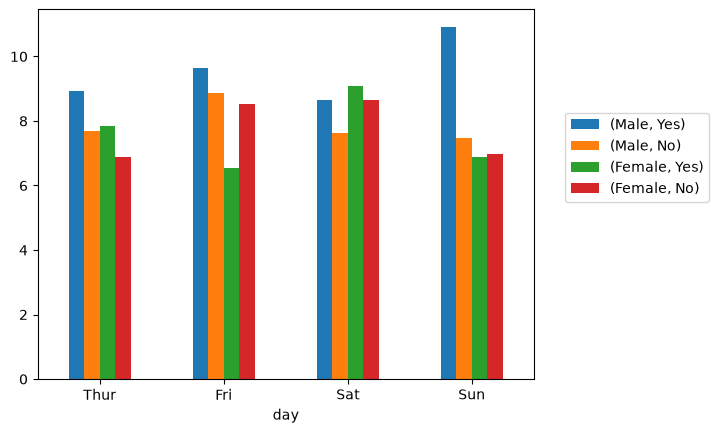

In [131]:
ax = tips5.T.plot.bar(rot=0)
ax.legend(bbox_to_anchor=(1.05, 0.6), loc='center left') 
plt.show()

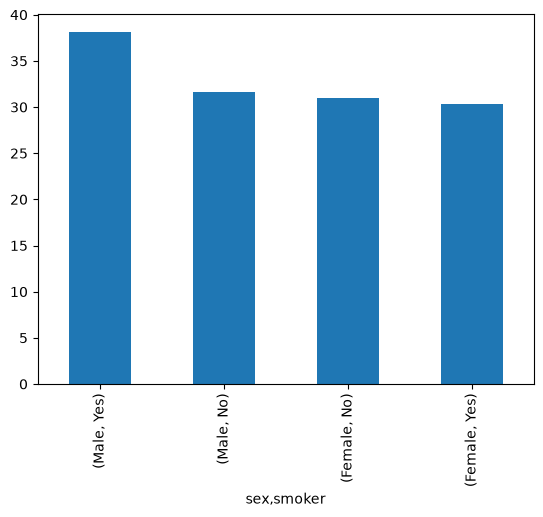

In [124]:
tips5.T.sum().sort_values(ascending=False).plot.bar()
plt.show()